# 05 - Hyperparameter Optimization, Explainability, Threshold Selection and Final Test Evaluation

| | |
|---|---|
| **Input** | `model_ready_train.csv`, `model_ready_val.csv` (46,026 / 7,890 orders, 28 features). `model_ready_test.csv` is opened **once**, in section 8. |
| **Output** | Tuned models in `models/`, best parameters, `chosen_threshold.json`, `final_test_results.json`, and figures in `reports/figures/` |
| **Replaces** | the experiment notebooks `01_optuna_random_forest`, `02_optuna_xgboost` (v1 and v2), `03_optuna_neural_network`, `04_shap_analysis`, `05_threshold_tuning`, `06_final_test_evaluation` |

## What this notebook does

| Section | Question it answers |
|---|---|
| 1. Setup | Load train and validation data, set the run options |
| 2. Random Forest | Does Optuna tuning improve the Recall leader from the model development stage? |
| 3. XGBoost | Same question, and why the first (Recall-only) attempt was thrown away |
| 4. Neural Network | Does tuning close the gap to Random Forest? |
| 5. Model selection | Which tuned model goes forward, compared fairly at the same Recall? |
| 6. SHAP | What is the model really using, and does `order_hour` matter? |
| 7. Threshold | Which operating point do we choose, using validation data only? |
| 8. Final test | How well does the final model and threshold do on data it has never seen? |
| 9. Summary | The numbers and caveats that feed Stage 9 (recommendation) |

## Headline results

- **Final model:** tuned Random Forest. All three tuned models are tied at the operating point we actually use (about 0.64 Precision at 0.80 Recall on validation), so the choice between them is not critical.
- **Chosen threshold:** 0.38, picked from a Recall target of 0.80. A cost-ratio rule was tried first and rejected, because with a 55% late rate it simply flags almost every order.
- **Test result:** Recall 0.882, Precision 0.606, ROC-AUC 0.752. About 80% of orders are flagged, so this works as a broad watch list. The top 10% of orders by risk score are all late (mostly First Class and Same Day orders placed after noon), which makes the ranking more useful than the yes/no flag.



## 1. Setup

In [1]:
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

RUN_SEARCH = False         
                           
N_TRIALS_RF, N_TRIALS_XGB, N_TRIALS_NN = 50, 50, 30
SHAP_SAMPLE_SIZE = 1000    #validation rows used for SHAP
USE_SHAP_CACHE = True      
TARGET_RECALL = 0.80       #operating point for the threshold 
SEED = 42

DATA = Path('../data/processed')
MODELS = Path('../models')
FIGS = Path('../reports/figures')
for p in (DATA, MODELS, FIGS):
    p.mkdir(parents=True, exist_ok=True)

train_df = pd.read_csv(DATA / 'model_ready_train.csv')
val_df = pd.read_csv(DATA / 'model_ready_val.csv')

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")
print(f"Late share: train {y_train.mean():.3f}, validation {y_val.mean():.3f}")

X_train: (46026, 28), X_val: (7890, 28)
Late share: train 0.548, validation 0.542


In [2]:
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                             average_precision_score, precision_recall_curve,
                             confusion_matrix, classification_report, roc_curve)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def metric_row(y_true, score, threshold=0.5):
    """The five headline metrics. Recall and Precision are at the given threshold;
    ROC-AUC and PR-AUC do not depend on it."""
    pred = (np.asarray(score) >= threshold).astype(int)
    return {'Recall': recall_score(y_true, pred),
            'Precision': precision_score(y_true, pred),
            'F1': f1_score(y_true, pred),
            'ROC-AUC': roc_auc_score(y_true, score),
            'PR-AUC': average_precision_score(y_true, score)}

def untuned_metrics(name):
    """Validation metrics of the default-settings model, saved by the model development notebook."""
    m = json.load(open(DATA / f'metrics_{name}.json'))
    return {'Recall': m['recall'], 'Precision': m['precision'], 'F1': m['f1'],
            'ROC-AUC': m['roc_auc'], 'PR-AUC': m['pr_auc']}

def precision_at_recall(y_true, score, target_recall):
    """Best Precision achievable at (or above) a given Recall: a threshold-free way to compare models."""
    prec, rec, _ = precision_recall_curve(y_true, score)
    ok = prec[rec >= target_recall]
    return ok.max() if len(ok) else float('nan')

def load_params(path, fallback):
    """Best parameters saved by an earlier search; falls back to the recorded values if the file is missing."""
    try:
        with open(path) as f:
            return json.load(f)
    except FileNotFoundError:
        return fallback

def run_study(objective, n_trials, name):
    """Run an Optuna study with a progress line per trial."""
    start = time.time()
    def progress(study, trial):
        done = len(study.trials)
        elapsed = time.time() - start
        print(f"Trial {done}/{n_trials} | {trial.duration.total_seconds():.0f}s | "
              f"elapsed {elapsed/60:.1f} min | ETA {elapsed/done*(n_trials-done)/60:.1f} min | "
              f"best so far {study.best_value:.4f}")
    study = optuna.create_study(direction='maximize', study_name=name)
    study.optimize(objective, n_trials=n_trials, callbacks=[progress])
    print(f"Best validation score: {study.best_value:.4f}")
    return study

def save_study_plots(study, history_file, importance_file):
    from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances
    for fn, fname in [(plot_optimization_history, history_file), (plot_param_importances, importance_file)]:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            fn(study)
        plt.tight_layout()
        plt.savefig(FIGS / fname, dpi=120, bbox_inches='tight')
        plt.show()

## 2. Random Forest

Random Forest was the Recall leader at default settings (Recall 0.6172), so it is tuned first. One Optuna trial is one fit plus one score on the fixed validation set, as logged in the decision log (running full cross validation inside every trial would be too slow). The objective is validation **Recall**.

> **Note:** this is the one model tuned on Recall. XGBoost and the Neural Network were tuned on PR-AUC (sections 3 and 4) after the Recall objective proved misleading for XGBoost. The Random Forest result is checked against the ranking metrics below and holds up, so it was not re run.

In [3]:
from sklearn.ensemble import RandomForestClassifier

def rf_objective(trial):
    if trial.suggest_categorical('max_depth_is_none', [True, False]):
        max_depth = None
    else:
        max_depth = trial.suggest_int('max_depth', 5, 50)
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': max_depth,
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced']),
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = RandomForestClassifier(**params).fit(X_train, y_train)
    return recall_score(y_val, model.predict(X_val))

RF_FALLBACK = {'max_depth': 50, 'n_estimators': 124, 'min_samples_split': 5,
               'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}

if RUN_SEARCH:
    study_rf = run_study(rf_objective, N_TRIALS_RF, 'rf_recall_tuning')
    rf_params = dict(study_rf.best_params)
    if rf_params.pop('max_depth_is_none'):
        rf_params['max_depth'] = None
    save_study_plots(study_rf, 'rf_optimization_history.png', 'rf_param_importance.png')
    json.dump(rf_params, open(DATA / 'optuna_rf_best_params.json', 'w'), indent=2)
else:
    rf_params = load_params(DATA / 'optuna_rf_best_params.json', RF_FALLBACK)

print("Random Forest parameters:", rf_params)

Random Forest parameters: {'max_depth': 50, 'n_estimators': 124, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'class_weight': None}


**Search record (original run, 50 trials, about 60 minutes):**

- Best validation Recall **0.6289**, against 0.6172 for the untuned default (+1.2 points). The first run, capped at `max_depth=30`, scored 0.6125, below the default. Widening the range to 50 coincided with the improvement.
- Best parameters: `max_depth=50`, `n_estimators=124`, `min_samples_split=5`, `min_samples_leaf=1`, `max_features=None`, `class_weight=None`. `class_weight=None` fits the EDA finding that the classes are close to balanced, so reweighting had nothing to fix.
- The best value climbed from 0.591 (trial 1) to 0.6289 (trial 46). Most of the gain came between trials 20 and 33, and the search was close to plateauing.
- **Parameter importance:** `min_samples_split` (0.47) and `min_samples_leaf` (0.34) explain over 80% of the variation in Recall. `max_depth` and `max_features` mattered little, but `max_features` is low partly because the search settled on `None` early and rarely tried the alternatives.
- **Caveat:** the best of 50 trials scored on one validation set is optimistic by construction. Section 8 shows how much of it holds up on the test set.

In [4]:
rf_tuned = RandomForestClassifier(**rf_params, random_state=SEED, n_jobs=-1).fit(X_train, y_train)
joblib.dump(rf_tuned, MODELS / 'random_forest_tuned.pkl')

rf_val_score = rf_tuned.predict_proba(X_val)[:, 1]
rf_table = pd.DataFrame({'Untuned RF': untuned_metrics('rf'),
                         'Tuned RF': metric_row(y_val, rf_val_score)})
rf_table['Change'] = rf_table['Tuned RF'] - rf_table['Untuned RF']
rf_table.round(4)

,Untuned RF,Tuned RF,Change
Recall,0.6172,0.6289,0.0117
Precision,0.7924,0.7751,-0.0173
F1,0.6939,0.6944,0.0005
ROC-AUC,0.7580,0.7621,0.0041
PR-AUC,0.8234,0.8266,0.0032


**What we found: Random Forest's Recall only tuning genuinely helped, and it was not a threshold artifact.**

| Metric | Untuned RF | Tuned RF | Change |
|---|---|---|---|
| Recall | 0.6172 | 0.6289 | +0.0117 |
| Precision | 0.7924 | 0.7751 | -0.0173 |
| F1 | 0.6939 | 0.6944 | +0.0005 |
| ROC-AUC | 0.7580 | 0.7621 | +0.0041 |
| PR-AUC | 0.8234 | 0.8266 | +0.0032 |

Both ranking metrics improved alongside Recall, with a modest Precision cost and flat F1. That is exactly the pattern XGBoost's Recall-tuned version failed to show (section 3). The likely reason is that Random Forest has no equivalent of XGBoost's `learning_rate` and regularization strength, which can push probabilities toward the extremes and move many borderline orders across 0.5 without any real gain in ranking. The only way to raise Recall in a Random Forest search is to find trees that separate the classes better, which is what the improved AUCs confirm.

## 3. XGBoost

XGBoost was the backup candidate (Recall 0.6062 at default settings, statistically tied with LightGBM and CatBoost).

### The first attempt was discarded: Recall is the wrong objective

The first search maximized validation Recall at the 0.5 threshold. It reached Recall 0.6773, which looked like a +7 point win. The full metrics check showed it was not:

| Metric | Untuned XGBoost | Tuned (Recall objective) | Change |
|---|---|---|---|
| Recall | 0.6062 | 0.6773 | +0.0711 |
| Precision | 0.8160 | 0.7060 | -0.1100 |
| F1 | 0.6956 | 0.6913 | -0.0043 |
| ROC-AUC | 0.7595 | 0.7405 | -0.0190 |
| PR-AUC | 0.8250 | 0.8063 | -0.0187 |

The model had simply moved its operating point toward predicting "Late" more often. Precision fell 11 points and both ranking metrics got worse. We already have a proper tool for trading Recall against Precision (threshold selection, section 7), so asking Optuna to do it implicitly, with no cost on false alarms, only pushes the model toward over-flagging.

**The fix:** tune for ranking quality (**PR-AUC**), which does not depend on the threshold, and choose the operating point separately. This also suits the prioritization lens, which depends on how well the model orders orders by risk. The search below uses that objective.

In [5]:
from xgboost import XGBClassifier

def xgb_objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': SEED,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params).fit(X_train, y_train)
    return average_precision_score(y_val, model.predict_proba(X_val)[:, 1])

XGB_FALLBACK = {'n_estimators': 426, 'max_depth': 10, 'learning_rate': 0.013340015325724125,
                'subsample': 0.9894698970107478, 'colsample_bytree': 0.9667071475768111,
                'min_child_weight': 1, 'gamma': 4.945734128000581,
                'reg_alpha': 1.604075589450644e-07, 'reg_lambda': 8.145043394425596e-08}

if RUN_SEARCH:
    study_xgb = run_study(xgb_objective, N_TRIALS_XGB, 'xgb_prauc_tuning')
    xgb_params = dict(study_xgb.best_params)
    save_study_plots(study_xgb, 'xgb_optuna_history.png', 'xgb_optuna_importances.png')
    json.dump(xgb_params, open(DATA / 'optuna_xgb_best_params.json', 'w'), indent=2)
else:
    xgb_params = load_params(DATA / 'optuna_xgb_best_params.json', XGB_FALLBACK)

print("XGBoost parameters:", xgb_params)

XGBoost parameters: {'n_estimators': 426, 'max_depth': 10, 'learning_rate': 0.013340015325724125, 'subsample': 0.9894698970107478, 'colsample_bytree': 0.9667071475768111, 'min_child_weight': 1, 'gamma': 4.945734128000581, 'reg_alpha': 1.604075589450644e-07, 'reg_lambda': 8.145043394425596e-08}


**Search record (original run, 50 trials, about 1 minute):**

- Best validation PR-AUC **0.8325**, up from 0.8250 untuned (+0.0075). That is a small gain, which is the honest size of what tuning adds here, not the inflated 7 points from the Recall objective.
- Best parameters describe a slow-and-steady model: `learning_rate=0.013` (the Recall run chose 0.25), `n_estimators=426`, `max_depth=10`, `subsample=0.99`, `colsample_bytree=0.97`, `gamma=4.95`, `min_child_weight=1`, and almost no L1/L2 penalty.
- The best value jumped from 0.823 to 0.832 by trial 4 and added only about 0.001 over the remaining 46 trials, so the search could have stopped around trial 10.
- **Parameter importance changed completely** compared with the Recall run: `subsample` (0.29), `gamma` (0.22) and `colsample_bytree` (0.17) led here, while `reg_alpha` and `learning_rate` led before. Chasing Recall rewards aggressive, fast fitting. Chasing PR-AUC rewards overfitting control through sampling and the split penalty.

In [6]:
xgb_tuned = XGBClassifier(**xgb_params, eval_metric='logloss', random_state=SEED, n_jobs=-1).fit(X_train, y_train)
joblib.dump(xgb_tuned, MODELS / 'xgboost_tuned.pkl')

# Default-settings XGBoost from the model development notebook, refit to get its scores for the matched-Recall check
xgb_untuned = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                            eval_metric='logloss', random_state=SEED, n_jobs=-1).fit(X_train, y_train)

xgb_val_score = xgb_tuned.predict_proba(X_val)[:, 1]
xgb_untuned_score = xgb_untuned.predict_proba(X_val)[:, 1]

xgb_table = pd.DataFrame({'Untuned XGBoost': metric_row(y_val, xgb_untuned_score),
                          'Tuned XGBoost': metric_row(y_val, xgb_val_score)})
xgb_table['Change'] = xgb_table['Tuned XGBoost'] - xgb_table['Untuned XGBoost']
print("All metrics at the default 0.5 threshold:")
display(xgb_table.round(4))

matched = pd.DataFrame([{'Target Recall': t,
                         'Untuned precision': precision_at_recall(y_val, xgb_untuned_score, t),
                         'Tuned precision': precision_at_recall(y_val, xgb_val_score, t)}
                        for t in [0.60, 0.65, 0.70, 0.75]])
matched['Difference'] = matched['Tuned precision'] - matched['Untuned precision']
print("Precision at matched Recall levels:")
display(matched.round(4))

All metrics at the default 0.5 threshold:


,Untuned XGBoost,Tuned XGBoost,Change
Recall,0.6062,0.5875,-0.0187
Precision,0.8160,0.8462,0.0302
F1,0.6956,0.6935,-0.0021
ROC-AUC,0.7595,0.7684,0.0089
PR-AUC,0.8250,0.8322,0.0072


Precision at matched Recall levels:


,Target Recall,Untuned precision,Tuned precision,Difference
0,0.60,0.8261,0.8308,0.0047
1,0.65,0.7599,0.7721,0.0122
2,0.70,0.7033,0.7223,0.0190
3,0.75,0.6680,0.6789,0.0109


**What we found: this is a real improvement, confirmed two ways.**

At the default 0.5 threshold the tuned model has *lower* Recall (0.5875 vs 0.6062) but higher Precision (0.846 vs 0.816), ROC-AUC (about 0.769 vs 0.7595) and PR-AUC (about 0.832 vs 0.825). On its own that could still be a different threshold trade, so the real test is the matched-Recall table. At every Recall level tested, the tuned model has higher Precision (roughly +0.5 to +2 points). At the *same* Recall it gets more of its "Late" flags right, which can only happen if it ranks orders better. The gain is modest but real, which is what an objective built to reward ranking quality should produce.

## 4. Neural Network

The Neural Network had the best ROC-AUC, PR-AUC and Precision at default settings but trailed Random Forest on Recall. This section asks whether tuning the architecture and training settings closes that gap.

Each trial trains a full small network for 15 epochs, so trials are much slower than the tree models. The trial count is deliberately lower (30 instead of 50) to keep the runtime reasonable. The objective is PR-AUC, for the reason given in section 3. Inputs are standardized with a scaler fit on the training set only.

> An earlier Neural Network run used a Recall objective and produced a degenerate "best score of 1.0". The smoke test below was added after that, and it takes about a minute. It should print a PR-AUC around 0.82 to 0.84. If it prints about 1.0, something is leaking and the search should not be run.

In [7]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler

torch.set_num_threads(4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

scaler = StandardScaler().fit(X_train)
X_train_np = scaler.transform(X_train).astype(np.float32)
X_val_np = scaler.transform(X_val).astype(np.float32)
y_train_np = y_train.to_numpy().astype(np.float32)
n_features = X_train_np.shape[1]

class ConfigurableMLP(nn.Module):
    def __init__(self, n_features, hidden1, hidden2, dropout1, dropout2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, hidden1), nn.ReLU(), nn.Dropout(dropout1),
            nn.Linear(hidden1, hidden2), nn.ReLU(), nn.Dropout(dropout2),
            nn.Linear(hidden2, 1),
        )
    def forward(self, x):
        return self.net(x)

def train_mlp(p, n_epochs):
    torch.manual_seed(SEED)
    loader = DataLoader(TensorDataset(torch.tensor(X_train_np), torch.tensor(y_train_np)),
                        batch_size=p['batch_size'], shuffle=True)
    model = ConfigurableMLP(n_features, p['hidden1'], p['hidden2'], p['dropout1'], p['dropout2']).to(device)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=p['lr'], weight_decay=p['weight_decay'])
    for _ in range(n_epochs):
        model.train()
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            criterion(model(xb).squeeze(1), yb).backward()
            optimizer.step()
    return model

def mlp_score(model, X_np):
    model.eval()
    with torch.no_grad():
        logits = model(torch.tensor(X_np).to(device)).squeeze(1).cpu().numpy()
    return 1 / (1 + np.exp(-logits))

def nn_objective(trial):
    p = {'hidden1': trial.suggest_categorical('hidden1', [32, 64, 128]),
         'hidden2': trial.suggest_categorical('hidden2', [16, 32, 64]),
         'dropout1': trial.suggest_float('dropout1', 0.1, 0.5),
         'dropout2': trial.suggest_float('dropout2', 0.1, 0.5),
         'lr': trial.suggest_float('lr', 1e-4, 5e-3, log=True),
         'weight_decay': trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True),
         'batch_size': trial.suggest_categorical('batch_size', [128, 256, 512])}
    model = train_mlp(p, n_epochs=15)
    return average_precision_score(y_val, mlp_score(model, X_val_np))

NN_FALLBACK = {'hidden1': 64, 'hidden2': 32, 'dropout1': 0.1483369425619312, 'dropout2': 0.31768647975092346,
               'lr': 0.0013317437780275565, 'weight_decay': 3.126956503461717e-06, 'batch_size': 256}

if RUN_SEARCH:
    smoke = nn_objective(optuna.trial.FixedTrial({'hidden1': 64, 'hidden2': 32, 'dropout1': 0.3, 'dropout2': 0.3,
                                                  'lr': 1e-3, 'weight_decay': 1e-4, 'batch_size': 256}))
    print("Smoke-test PR-AUC:", round(smoke, 4), "(expect about 0.82 to 0.84)")
    study_nn = run_study(nn_objective, N_TRIALS_NN, 'nn_prauc_tuning')
    nn_params = dict(study_nn.best_params)
    json.dump(nn_params, open(DATA / 'optuna_nn_best_params.json', 'w'), indent=2)
else:
    nn_params = load_params(DATA / 'optuna_nn_best_params.json', NN_FALLBACK)

print("Neural Network parameters:", nn_params)

Neural Network parameters: {'hidden1': 64, 'hidden2': 32, 'dropout1': 0.1483369425619312, 'dropout2': 0.31768647975092346, 'lr': 0.0013317437780275565, 'weight_decay': 3.126956503461717e-06, 'batch_size': 256}


**Search record (original run, 30 trials, about 20 minutes, individual trials 21 to 72 seconds):**

The smoke test passed (PR-AUC 0.8295 on a fixed configuration). The best validation PR-AUC after 30 trials was **0.8307, barely above the untuned network's 0.8301 (+0.0006)**. That is essentially no gain, unlike Random Forest (+0.0032) or XGBoost (+0.0075). The best parameters (`lr=0.0013`, `hidden1=64`, `hidden2=32`, `batch_size=256`) all sit comfortably inside their search ranges, so this is not a search-space limit. The untuned architecture was already close to the best this search space allows.

In [8]:
# Retrain the best configuration for longer (40 epochs) now that the settings are fixed
nn_tuned = train_mlp(nn_params, n_epochs=40)
torch.save(nn_tuned.state_dict(), MODELS / 'neural_network_tuned.pt')
joblib.dump(scaler, MODELS / 'nn_scaler.pkl')

nn_val_score = mlp_score(nn_tuned, X_val_np)
nn_table = pd.DataFrame({'Untuned NN': untuned_metrics('nn'),
                         'Tuned NN': metric_row(y_val, nn_val_score)})
nn_table['Change'] = nn_table['Tuned NN'] - nn_table['Untuned NN']
nn_table.round(4)

,Untuned NN,Tuned NN,Change
Recall,0.5857,0.5868,0.0012
Precision,0.8458,0.8460,0.0003
F1,0.6921,0.6930,0.0009
ROC-AUC,0.7653,0.7657,0.0004
PR-AUC,0.8301,0.8291,-0.0010


**What we found: essentially no change in either direction.** Every difference is within about 0.1 percentage point, which is smaller than the variation between random seeds. ROC-AUC and PR-AUC did not move together with Recall, but they did not collapse either. This is not the pattern from XGBoost's first attempt (Precision -11 points, ROC-AUC -1.9 points). It is noise around a flat line.

Tuning the layer sizes, dropout, learning rate, weight decay and batch size did not change this network's behavior. The two reasonable explanations are that a two-hidden-layer network is already near its ceiling for 46,026 rows and 28 features, or that the defaults chosen in the model development stage were already a solid configuration. Either way, there is no reason to prefer the tuned network over the untuned one.

## 5. Model selection: which tuned model goes forward?

At the default 0.5 threshold the three models look different (Random Forest has the best Recall, the others the best Precision), but that mostly reflects where each model draws its line. The fair comparison is Precision **at the same Recall**, because the final threshold will be chosen from a Recall target in section 7.

Tuned models, validation set, default 0.5 threshold:


,Random Forest,XGBoost,Neural Network
Recall,0.6289,0.5875,0.5868
Precision,0.7751,0.8462,0.8460
F1,0.6944,0.6935,0.6930
ROC-AUC,0.7621,0.7684,0.7657
PR-AUC,0.8266,0.8322,0.8291


Precision at matched Recall:


,Random Forest,XGBoost,Neural Network
Target Recall,,,
0.60,0.8119,0.8308,0.8136
0.65,0.7582,0.7721,0.7576
0.70,0.7039,0.7223,0.7188
0.75,0.6666,0.6789,0.6745
0.80,0.6405,0.6399,0.6445
0.85,0.6171,0.6169,0.6162
0.90,0.5921,0.5937,0.5911


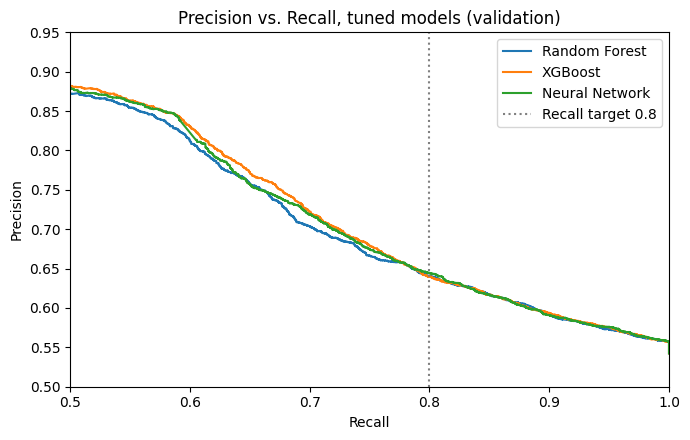

In [9]:
val_scores = {'Random Forest': rf_val_score, 'XGBoost': xgb_val_score, 'Neural Network': nn_val_score}

print("Tuned models, validation set, default 0.5 threshold:")
display(pd.DataFrame({name: metric_row(y_val, s) for name, s in val_scores.items()}).round(4))

targets = [0.60, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90]
matched_all = pd.DataFrame({name: [precision_at_recall(y_val, s, t) for t in targets]
                            for name, s in val_scores.items()}, index=pd.Index(targets, name='Target Recall'))
print("Precision at matched Recall:")
display(matched_all.round(4))

fig, ax = plt.subplots(figsize=(7, 4.5))
for name, s in val_scores.items():
    prec, rec, _ = precision_recall_curve(y_val, s)
    ax.plot(rec, prec, label=name)
ax.axvline(TARGET_RECALL, color='gray', linestyle=':', label=f'Recall target {TARGET_RECALL}')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision'); ax.set_xlim(0.5, 1.0); ax.set_ylim(0.5, 0.95)
ax.set_title('Precision vs. Recall, tuned models (validation)'); ax.legend()
plt.tight_layout()
plt.savefig(FIGS / 'tuned_models_precision_recall.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found: the three tuned models are tied at the operating point we actually use.**

- At a Recall of 0.80 and above, Precision is about **0.64** for Random Forest, XGBoost and the Neural Network, within half a point of each other. At 0.85 and 0.90 the gaps are even smaller.
- At lower Recall targets (0.60 to 0.75) **XGBoost is ahead by about 1 to 2 points** of Precision, with the Neural Network close to Random Forest or in between. That is the region of the curve we are not using.
- In ranking terms (ROC-AUC, PR-AUC), XGBoost is the best tuned model by a small margin, and Random Forest the weakest of the three. The differences are around 0.005 to 0.01.

**Decision: the final model is the tuned Random Forest.** It was the Recall leader going into tuning, it is the model the later threshold and test sections are built on, and at a Recall of 0.80 it is not worse than the alternatives. This is a defensible choice rather than a clear win: XGBoost is an equally good alternative and is much faster to explain with SHAP (1 second against about 15 minutes). If a later stage needs a lighter or faster model, XGBoost can replace it with no real loss at this operating point.

## 6. SHAP explainability

This settles the `order_hour` question left open since the model development stage: Random Forest's permutation importance ranked it 2nd, but XGBoost's gain-based importance ranked it near last. SHAP does not share the cardinality and split-count biases of either built-in measure. It also prototypes the app's planned "why is this risky?" panel.

`shap.TreeExplainer` on a Random Forest costs (trees x depth x rows), and this forest has 124 trees at depth up to 50. So SHAP is run on a **random sample of 1,000 validation rows** instead of all 7,890. Summary and dependence plots show overall patterns, so a sample of this size gives a near-identical picture. The Random Forest SHAP values take about 15 minutes, so they are saved and reused (`USE_SHAP_CACHE`). Delete `models/shap_values_rf_n*.npy` if the Random Forest is ever retrained with different parameters.

In [10]:
import shap

X_val_shap = X_val.sample(n=min(SHAP_SAMPLE_SIZE, len(X_val)), random_state=SEED)
print(f"Using {len(X_val_shap)} sampled rows (of {len(X_val)}) for all SHAP computations.")

def positive_class_shap(sv):
    """Return a 2D (rows x features) SHAP array for the 'Late' class (class 1), whatever format
    the installed SHAP version returns: a list of two arrays (old), a 3D array (new), or 2D (XGBoost)."""
    if isinstance(sv, list):
        return np.asarray(sv[1])
    sv = np.asarray(sv)
    return sv[:, :, 1] if sv.ndim == 3 else sv

def positive_class_base(ev):
    ev = np.atleast_1d(np.asarray(ev))
    return float(ev[1] if ev.size > 1 else ev[0])

Using 1000 sampled rows (of 7890) for all SHAP computations.


### 6.1 Random Forest

Loaded saved SHAP values from shap_values_rf_n1000.npy
raw SHAP output shape: (1000, 28, 2) -> using (1000, 28)


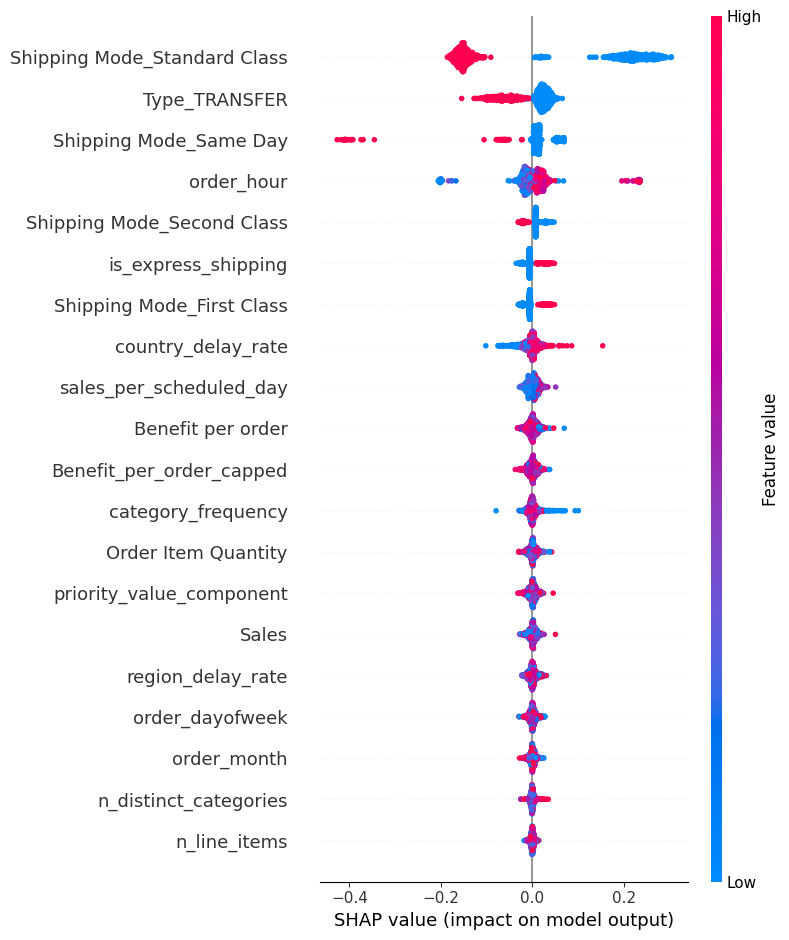

In [11]:
explainer_rf = shap.TreeExplainer(rf_tuned)
cache_path = MODELS / f'shap_values_rf_n{len(X_val_shap)}.npy'

shap_values_rf = None
if USE_SHAP_CACHE and cache_path.exists():
    cached = np.load(cache_path)
    if cached.shape[0] == len(X_val_shap) and cached.shape[1] == X_val_shap.shape[1]:
        shap_values_rf = cached
        print(f"Loaded saved SHAP values from {cache_path.name}")
if shap_values_rf is None:
    t0 = time.time()
    print("Computing Random Forest SHAP values (about 15 minutes)...")
    shap_values_rf = explainer_rf.shap_values(X_val_shap, check_additivity=False)
    np.save(cache_path, np.asarray(shap_values_rf))
    print(f"  done in {time.time()-t0:.0f}s, saved to {cache_path.name}")

sv_rf = positive_class_shap(shap_values_rf)
base_rf = positive_class_base(explainer_rf.expected_value)
print("raw SHAP output shape:", np.shape(shap_values_rf), "-> using", sv_rf.shape)

shap.summary_plot(sv_rf, X_val_shap, show=False)
plt.tight_layout()
plt.savefig(FIGS / 'shap_summary_rf.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found (Random Forest):** `order_hour` ranks **4th of 28** features by mean absolute SHAP value, behind `Shipping Mode_Standard Class`, `Type_TRANSFER` and `Shipping Mode_Same Day`, and ahead of `Shipping Mode_Second Class`, `is_express_shipping`, `Shipping Mode_First Class` and `country_delay_rate`. So SHAP confirms the permutation-importance result: in the Random Forest, `order_hour` really is an important feature, not an artifact of the default importance measure.

Shipping Mode as a whole still dominates. The Shipping Mode dummies and `is_express_shipping` take 5 of the top 8 slots, and `Shipping Mode_Standard Class` alone is about five times as important as the next feature. The directions match EDA: Standard Class = 1 (red) pushes predicted risk down (Standard Class had the lowest late rate, 38%), while First Class and `is_express_shipping` = 1 push it up. Credit is split across the Shipping Mode dummies because they are correlated, so no single dummy shows the full Shipping Mode effect.

Two further observations:
- `Type_TRANSFER` ranks 2nd and pushes risk down whenever it equals 1. That is a stronger payment-type effect than anything in EDA suggested, and it is worth a look before the final report.
- `order_hour` does not behave like a smooth effect across all orders. Most orders sit in a tight band near zero, and two small, separate groups sit at about -0.2 (early hours) and +0.2 (late hours). Much of its importance comes from those groups. Section 6.3 explains who they are.

### 6.2 XGBoost

XGBoost SHAP values computed in 1.2s, shape (1000, 28)


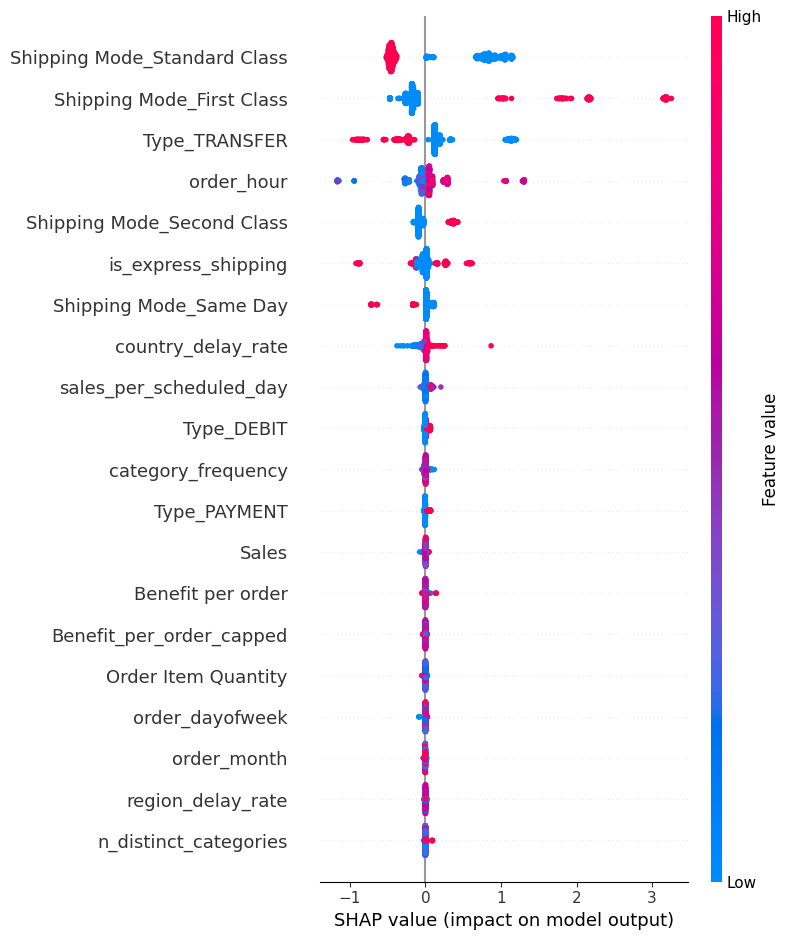

In [12]:
t0 = time.time()
explainer_xgb = shap.TreeExplainer(xgb_tuned)
sv_xgb = positive_class_shap(explainer_xgb.shap_values(X_val_shap, check_additivity=False))
print(f"XGBoost SHAP values computed in {time.time()-t0:.1f}s, shape {sv_xgb.shape}")

shap.summary_plot(sv_xgb, X_val_shap, show=False)
plt.tight_layout()
plt.savefig(FIGS / 'shap_summary_xgb.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found (XGBoost):** `order_hour` ranks **5th of 28** by mean absolute SHAP value, behind Standard Class, First Class, `Type_TRANSFER` and Second Class. This is the opposite of what XGBoost's gain based importance showed (near last), so the earlier chart was misleading, not the feature.

**The two models agree on the main picture.** Both put Shipping Mode, `Type_TRANSFER` and `order_hour` in the top 5, and both rank `country_delay_rate` below `order_hour`. Both also show the same pattern of a few separate groups of `order_hour` points far from zero. That makes the answer to the open question fairly solid: **`order_hour` is a top-5 feature in both tuned models once it is measured with SHAP.**

Differences to keep in mind:
- XGBoost's SHAP values are in log odds and Random Forest's are in probability units, so compare the *rankings* of the two plots, not the widths of the axes.
- XGBoost ranks First Class 2nd, while Random Forest ranks it 7th and gives Same Day more credit. The Shipping Mode dummies carry overlapping information, so SHAP splits credit between them differently in each model. This is not a real disagreement about Shipping Mode.
- XGBoost also uses the other payment types (`Type_DEBIT`, `Type_PAYMENT`, `Type_CASH`), but with much smaller effects.

### 6.3 Dependence plot: does `order_hour` interact with Shipping Mode?

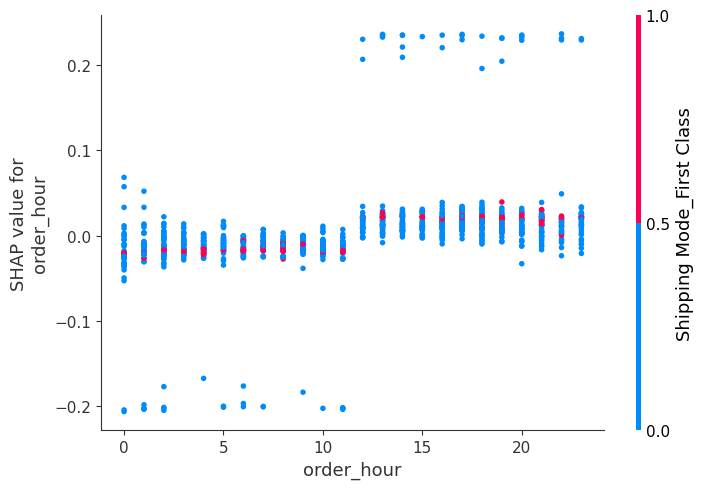

In [13]:
shap.dependence_plot('order_hour', sv_rf, X_val_shap,
                     interaction_index='Shipping Mode_First Class', show=False)
plt.tight_layout()
plt.savefig(FIGS / 'shap_dependence_order_hour.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found:** the interaction hypothesis, *as tested here*, is **not supported**. Coloring by `Shipping Mode_First Class` does not split the points. Nearly every point is blue (not First Class), and the few red points sit inside the main band and do not separate from the blue ones at the same hour.

What the plot does show:
- **A step at noon.** In the main band, orders placed before 12:00 have a slightly negative SHAP value (about -0.01) and orders from 12:00 onward a slightly positive one (about +0.01). That is a small effect, a percentage point or two of predicted probability, which fits EDA's finding that `order_hour` is a weak signal on its own.
- **Two separate groups far from the main band**, at about +0.2 (hours 12 to 23) and about -0.2 (hours 0 to 11). They follow the same noon split but are ten times larger than the main-band effect. Because they are not First Class orders, they depend on some other feature. The follow-up cells below find out which.

In [14]:
# Follow-up: which orders produce the large (+/-0.2) order_hour SHAP values?
i = list(X_val_shap.columns).index('order_hour')
big = np.abs(sv_rf[:, i]) > 0.1
print(f"{big.sum()} of {len(big)} sampled orders have |SHAP(order_hour)| > 0.1\n")

mode_cols = [c for c in X_val_shap.columns if c.startswith('Shipping Mode_')]
pd.DataFrame({
    'share in large-effect group': X_val_shap.loc[big, mode_cols].mean(),
    'share in all sampled orders': X_val_shap[mode_cols].mean(),
}).round(2)

53 of 1000 sampled orders have |SHAP(order_hour)| > 0.1



,share in large-effect group,share in all sampled orders
Shipping Mode_First Class,0.0,0.15
Shipping Mode_Same Day,1.0,0.05
Shipping Mode_Second Class,0.0,0.21
Shipping Mode_Standard Class,0.0,0.58


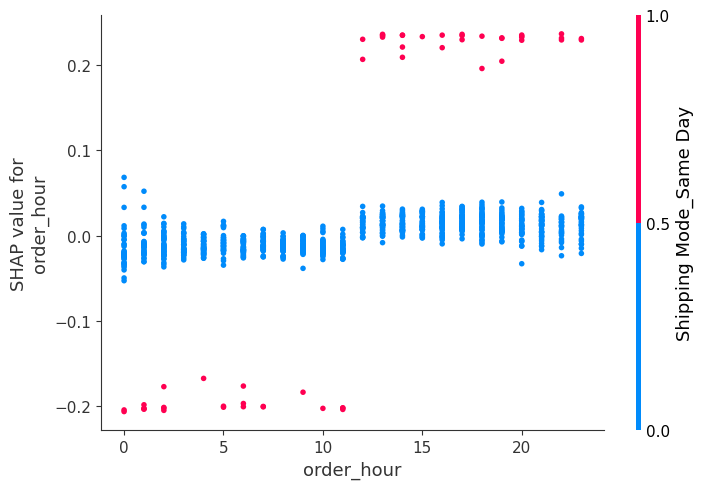

,late rate,orders
order_hour,,
placed 12:00 or later,0.96,1146
placed before 12:00,0.00,1332


In [15]:
# Same dependence plot, colored by Same Day shipping, plus the late rate behind it (training data)
shap.dependence_plot('order_hour', sv_rf, X_val_shap,
                     interaction_index='Shipping Mode_Same Day', show=False)
plt.tight_layout()
plt.savefig(FIGS / 'shap_dependence_order_hour_sameday.png', dpi=120, bbox_inches='tight')
plt.show()

same_day = X_train['Shipping Mode_Same Day'] == 1
placed = (X_train.loc[same_day, 'order_hour'] >= 12).map({False: 'placed before 12:00', True: 'placed 12:00 or later'})
sd_table = y_train[same_day].groupby(placed).agg(['mean', 'size'])
sd_table.columns = ['late rate', 'orders']
sd_table.round(3)

**What we found: the large `order_hour` effects belong to Same Day shipping, and the interaction is very strong.**

All 53 sampled orders with a large `order_hour` effect (|SHAP| above 0.1) are **Same Day** orders. Same Day is only 5% of the sample, so this is essentially every Same Day order. 30 of them were placed from 12:00 onward and pushed risk up, and 23 were placed before noon and pushed risk down. XGBoost's large-effect group (|SHAP| above 0.5, in its log-odds units) is the same 53 orders, so both models found the same thing.

The training data shows why. **Same Day orders placed before 12:00 were never late (0 of 1,332). Same Day orders placed at 12:00 or later were late 96% of the time (about 1,100 of 1,146).** The same pattern holds on the validation set (0% against about 95%). `order_hour` therefore matters through a single interaction: for Same Day shipping, the hour of the order decides almost everything.

This explains the original puzzle. EDA found `order_hour` flat because Same Day orders are only about 5 to 6% of the data, so the effect is invisible when all orders are averaged together. The default importance measures could see it because a tree uses the hour to split exactly those orders.

Two points for the report. First, this is not leakage: both the shipping mode and the order hour are known when the order is placed. Second, a split this clean (0% against 96%) looks like a rule built into the dataset, for example a same-day cutoff around noon, so it may be stronger than what real operations would show. It also makes a very explainable message for the app: "Same Day order placed after noon".

### 6.4 One order explained (prototype for the app panel)

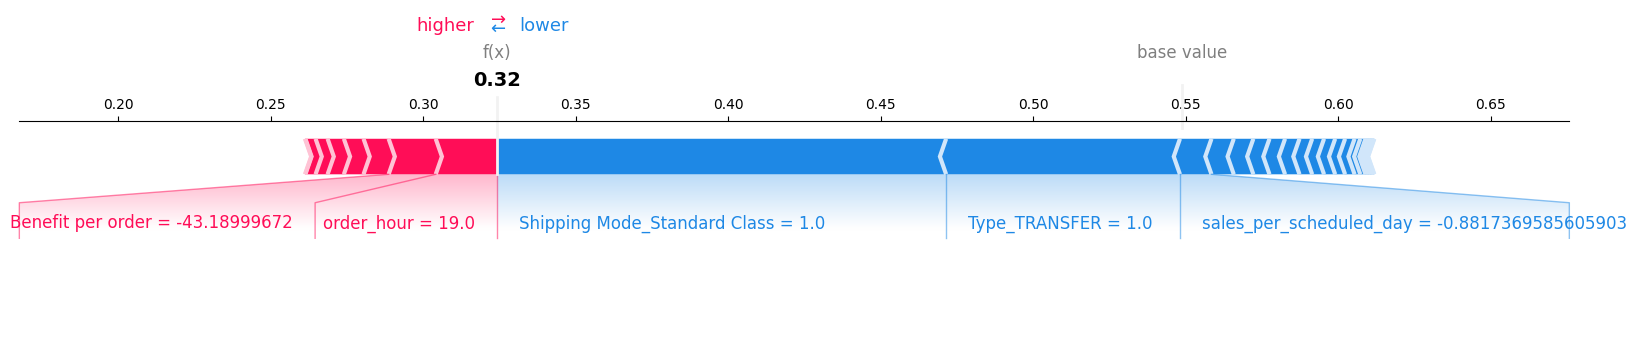

In [16]:
sample_idx = 0  # position within X_val_shap, not the original X_val

shap.force_plot(base_rf, sv_rf[sample_idx], X_val_shap.iloc[sample_idx], matplotlib=True, show=False)
plt.savefig(FIGS / 'shap_force_plot_example.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found:** this order (sample 0) has a predicted late-delivery probability of **0.32**, against a base value of about **0.55** (the average prediction), so the model rates it as **lower than average risk**.

- **Pushing risk down (blue):** `Shipping Mode_Standard Class = 1` is the largest push by far, followed by `Type_TRANSFER = 1` and `sales_per_scheduled_day`, plus many small contributions.
- **Pushing risk up (red):** `Benefit per order = -43.19` and `order_hour = 19`, but both are small compared with the blue side.

This matches the summary plots, so the explanation is consistent with how the model behaves overall. It is not yet ready for non-technical operations users, for three reasons:
1. Feature names are technical (`Shipping Mode_Standard Class = 1.0`). The app should say something like "shipped by Standard Class".
2. Values are mixed: `order_hour = 19.0` and `Benefit per order = -43.19` are raw, while `sales_per_scheduled_day = -0.88` is standardized and means nothing to an ops user. The app should show the unscaled value, as already planned for `priority_value_component`.
3. Showing the top 3 to 5 drivers in words ("Standard Class shipping lowers the risk the most") will read better than the full force plot with 28 labels.

## 7. Threshold selection (validation data only)

Every model so far was evaluated at the default 0.5 threshold. The business framing says a missed late delivery costs more than an unnecessary check, so the threshold should reflect that. All of this section uses the **validation set** and the tuned Random Forest.

### 7.1 A cost-based threshold, and why it fails here

Placeholder costs: a missed late order costs 3, a false alarm costs 1. The threshold that minimizes total expected cost is searched over a grid.

In [17]:
COST_FALSE_NEGATIVE = 3.0  # cost of missing an actual late order
COST_FALSE_POSITIVE = 1.0  # cost of flagging an order that turns out fine

y_score = rf_val_score
thresholds = np.arange(0.05, 0.95, 0.01)
results = []
for t in thresholds:
    y_pred_t = (y_score >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred_t).ravel()
    results.append({'threshold': t,
                    'recall': recall_score(y_val, y_pred_t),
                    'precision': precision_score(y_val, y_pred_t, zero_division=0),
                    'share_flagged': y_pred_t.mean(),
                    'fn': fn, 'fp': fp,
                    'expected_cost': fn * COST_FALSE_NEGATIVE + fp * COST_FALSE_POSITIVE})
results_df = pd.DataFrame(results)
best_threshold_row = results_df.loc[results_df['expected_cost'].idxmin()]
print(f"Threshold minimizing expected cost: {best_threshold_row['threshold']:.2f}")
print(f"At this threshold: Recall {best_threshold_row['recall']:.4f}, Precision {best_threshold_row['precision']:.4f}, "
      f"share of orders flagged {best_threshold_row['share_flagged']:.1%}")

# Reference points: what do the trivial strategies cost?
n_late = int(y_val.sum()); n_ontime = int((1 - y_val).sum())
row_05 = results_df.iloc[(results_df['threshold'] - 0.5).abs().argmin()]
print(f"\nExpected cost, flag nothing:      {n_late * COST_FALSE_NEGATIVE:,.0f}")
print(f"Expected cost, default 0.5:       {row_05['expected_cost']:,.0f}")
print(f"Expected cost, best threshold:    {best_threshold_row['expected_cost']:,.0f}")
print(f"Expected cost, flag EVERYTHING:   {n_ontime * COST_FALSE_POSITIVE:,.0f}")

Threshold minimizing expected cost: 0.11
At this threshold: Recall 0.9998, Precision 0.5575, share of orders flagged 97.3%

Expected cost, flag nothing:      12,837
Expected cost, default 0.5:       5,544
Expected cost, best threshold:    3,399
Expected cost, flag EVERYTHING:   3,611


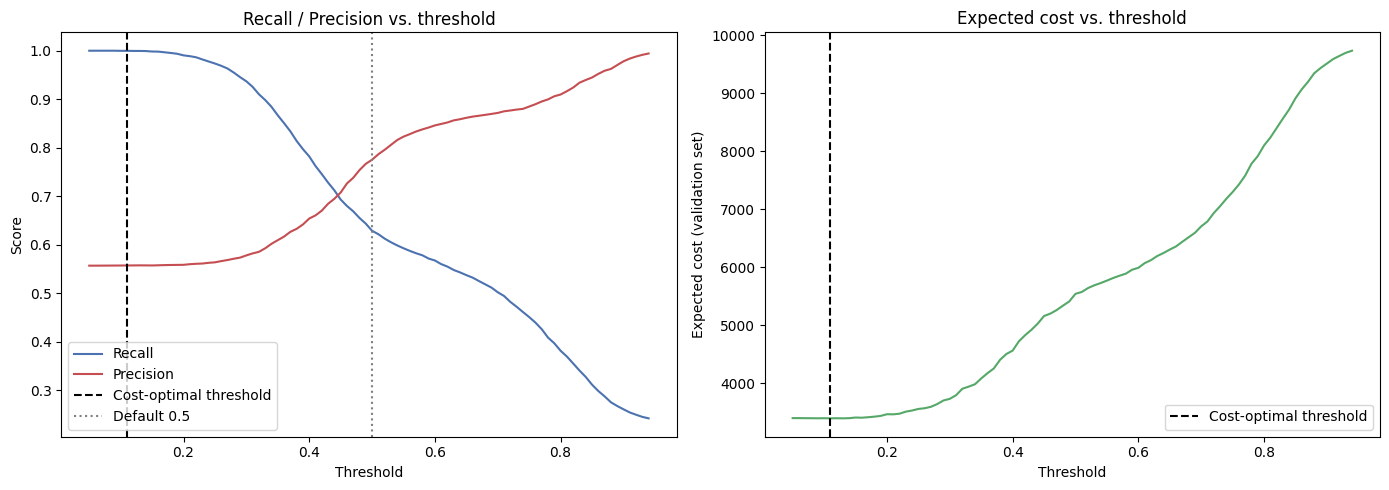

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(results_df['threshold'], results_df['recall'], label='Recall', color='#4C72B0')
axes[0].plot(results_df['threshold'], results_df['precision'], label='Precision', color='#C44E52')
axes[0].axvline(best_threshold_row['threshold'], color='black', linestyle='--', label='Cost-optimal threshold')
axes[0].axvline(0.5, color='gray', linestyle=':', label='Default 0.5')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score'); axes[0].legend()
axes[0].set_title('Recall / Precision vs. threshold')

axes[1].plot(results_df['threshold'], results_df['expected_cost'], color='#55A868')
axes[1].axvline(best_threshold_row['threshold'], color='black', linestyle='--', label='Cost-optimal threshold')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Expected cost (validation set)'); axes[1].legend()
axes[1].set_title('Expected cost vs. threshold')

plt.tight_layout()
plt.savefig(FIGS / 'threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()

**What we found:** with the placeholder 3:1 cost ratio the cost-optimal threshold is **0.11**, giving Recall **0.9998** and Precision **0.5575**. That looks like a big win over the default 0.5 (Recall 0.629, Precision 0.775), but it is **not a useful result**.

Precision of 0.5575 is almost exactly the late share in the validation set (54.2%). At this threshold the model flags about **97% of all orders**, which is the same as flagging everything. The reference costs confirm it: flagging everything costs 3,611, the "best" threshold costs 3,399 (only about 6% lower), and the default 0.5 costs about 5,544, which is *worse* than flagging everything.

The reason is arithmetic, not a bug. When more than half the orders are late and a miss costs 3 times a false alarm, "intervene on everything" is cheaper than any selective rule a model with a ROC-AUC of about 0.76 can produce. A cost matrix like this cannot produce a short, actionable list, which is the point of the project.

### 7.2 Does a different cost ratio fix it?

In [19]:
rows = []
for ratio in [1, 2, 3, 5, 10]:
    cost = results_df['fn'] * ratio + results_df['fp'] * 1.0
    r = results_df.loc[cost.idxmin()]
    rows.append({'FN:FP cost ratio': f"{ratio}:1", 'best threshold': round(r['threshold'], 2),
                 'recall': round(r['recall'], 3), 'precision': round(r['precision'], 3),
                 'share of orders flagged': f"{r['share_flagged']:.0%}"})
pd.DataFrame(rows)

,FN:FP cost ratio,best threshold,recall,precision,share of orders flagged
0,1:1,0.58,0.578,0.838,37%
1,2:1,0.13,1.000,0.558,97%
2,3:1,0.11,1.000,0.557,97%
3,5:1,0.09,1.000,0.557,97%
4,10:1,0.09,1.000,0.557,97%


**What we found:** only a ratio of 1:1 gives a selective rule (threshold 0.58, Recall 0.578, Precision 0.838, 37% of orders flagged), and that just means "treat both mistakes equally", which contradicts the Recall-first framing. From 2:1 upward the optimal rule flags 97% of orders. The best rule jumps from "selective" to "flag everything" somewhere between 1:1 and 2:1. The late share is 54%, so flagging everything is already cheap, and a model with this ranking quality cannot beat it once a miss costs even twice a false alarm.

**Conclusion:** a single cost ratio is the wrong tool for choosing the threshold on this dataset. The operating point is chosen from a Recall target and the share of orders ops can realistically act on instead.

### 7.3 Choose the threshold from a Recall target and a workload limit

For each Recall target, find the highest threshold that still reaches it (highest threshold = fewest orders flagged = best Precision), and report how many orders ops would have to act on. The top-K table is for the prioritization lens: if ops can only act on the K% riskiest orders, how clean is that list?

In [20]:
rows = []
for target in [0.65, 0.70, 0.75, 0.80, 0.85, 0.90]:
    ok = results_df[results_df['recall'] >= target]
    r = ok.loc[ok['threshold'].idxmax()]
    rows.append({'Recall target': target, 'threshold': round(r['threshold'], 2),
                 'recall': round(r['recall'], 3), 'precision': round(r['precision'], 3),
                 'share of orders flagged': f"{r['share_flagged']:.0%}"})
display(pd.DataFrame(rows))

def top_k_table(y_true, score, ks=(0.05, 0.10, 0.20, 0.30)):
    order = np.argsort(-np.asarray(score), kind='stable')
    y_sorted = np.asarray(y_true)[order]
    rows = []
    for k in ks:
        n = int(len(y_sorted) * k)
        top = y_sorted[:n]
        rows.append({'ops can act on': f"top {k:.0%} ({n} orders)",
                     'share that are truly late': round(top.mean(), 3),
                     'share of all late orders caught': round(top.sum() / y_sorted.sum(), 3)})
    return pd.DataFrame(rows)

display(top_k_table(y_val, y_score))

,Recall target,threshold,recall,precision,share of orders flagged
0,0.65,0.48,0.655,0.754,47%
1,0.70,0.44,0.712,0.695,56%
2,0.75,0.41,0.762,0.661,63%
3,0.80,0.38,0.814,0.633,70%
4,0.85,0.36,0.851,0.617,75%
5,0.90,0.32,0.910,0.586,84%


,ops can act on,share that are truly late,share of all late orders caught
0,top 5% (394 orders),1.000,0.092
1,top 10% (789 orders),1.000,0.184
2,top 20% (1578 orders),0.932,0.344
3,top 30% (2367 orders),0.877,0.485


**What we found:** Recall improves steadily as the threshold drops, and Precision falls with it:

| Recall target | Threshold | Precision | Orders flagged |
|---|---|---|---|
| 0.65 | 0.48 | 0.754 | 47% |
| 0.70 | 0.44 | 0.695 | 56% |
| 0.75 | 0.41 | 0.661 | 63% |
| 0.80 | 0.38 | 0.633 | 70% |
| 0.85 | 0.36 | 0.617 | 75% |
| 0.90 | 0.32 | 0.586 | 84% |

Going from the default 0.5 (Recall 0.629, Precision 0.775) to **0.38** buys about 18 points of Recall (to 0.81) for about 14 points of Precision, but ops then has to act on 70% of orders. The gain flattens above a 0.85 target: the last five points of Recall cost 9% more orders flagged and 3 more points of Precision.

For the prioritization lens, **the top of the ranking is very clean**: the 10% of orders with the highest risk scores are late 100% of the time (about 789 orders), and the top 20% are late 93% of the time. Ranking by risk, then by value, is where the model is most useful, more than the yes/no threshold.

**Recommended default for now: Recall target 0.80, threshold 0.38.** This is a placeholder for a group decision: the right target depends on how many orders ops can really check per day, which we do not know yet. Change `TARGET_RECALL` in section 1 to move it.

### 7.4 Who is in the top 10%?

The top of the ranking is perfectly clean, so it is worth checking what it is made of.

In [21]:
n_top = int(len(X_val) * 0.10)
top_idx = np.argsort(-y_score, kind='stable')[:n_top]
top10 = X_val.iloc[top_idx]
mode_cols_val = [c for c in X_val.columns if c.startswith('Shipping Mode_')]

print(f"Top 10% = {n_top} orders. Share by shipping mode:")
print(top10[mode_cols_val].mean().round(3).to_string())
same_day_pm = ((X_val['Shipping Mode_Same Day'] == 1) & (X_val['order_hour'] >= 12)).to_numpy()
print(f"\nSame Day orders placed 12:00 or later: {same_day_pm[top_idx].mean():.1%} of the top 10%")
print(f"Late rate of First Class orders overall (validation): {y_val[X_val['Shipping Mode_First Class'] == 1].mean():.3f}")

Top 10% = 789 orders. Share by shipping mode:
Shipping Mode_First Class       0.853
Shipping Mode_Same Day          0.147
Shipping Mode_Second Class      0.000
Shipping Mode_Standard Class    0.000

Same Day orders placed 12:00 or later: 14.7% of the top 10%
Late rate of First Class orders overall (validation): 0.946


**What we found:** the top 10% is made up entirely of **First Class orders (about 85%)** and **Same Day orders placed from 12:00 onward (about 15%)**. These are the two segments that were already about 95% late. So the clean top of the list is concentrated in the Shipping Mode segments that EDA flagged, not spread across all kinds of orders. The model does add something within those segments: the top 789 contain no on-time order, although First Class has some on-time orders, so it ranks the late ones above the on-time ones. But for the report, say plainly that the "top 10% are all late" result is largely a Shipping Mode result, and that the harder question is how well the model ranks the middle of the list.

In [22]:
ok = results_df[results_df['recall'] >= TARGET_RECALL]
chosen = ok.loc[ok['threshold'].idxmax()]

with open(DATA / 'chosen_threshold.json', 'w') as f:
    json.dump({
        'model': 'random_forest_tuned',
        'selection_rule': f'highest threshold with validation Recall >= {TARGET_RECALL}',
        'threshold': round(float(chosen['threshold']), 2),
        'validation_recall_at_threshold': float(chosen['recall']),
        'validation_precision_at_threshold': float(chosen['precision']),
        'validation_share_flagged': float(chosen['share_flagged']),
        'cost_optimal_threshold_for_reference': round(float(best_threshold_row['threshold']), 2),
        'cost_false_negative': COST_FALSE_NEGATIVE,
        'cost_false_positive': COST_FALSE_POSITIVE,
        'note': 'cost-optimal threshold flags ~97% of orders (degenerate), see notebook section 7',
    }, f, indent=2)

CHOSEN_THRESHOLD = round(float(chosen['threshold']), 2)
print(f"Saved chosen threshold {CHOSEN_THRESHOLD:.2f} "
      f"(validation Recall {chosen['recall']:.3f}, Precision {chosen['precision']:.3f}, {chosen['share_flagged']:.0%} flagged).")

Saved chosen threshold 0.38 (validation Recall 0.814, Precision 0.633, 70% flagged).


## 8. Final test set evaluation

**This is the one and only time the test set is opened.** Everything above, all model comparisons, tuning and threshold selection, used train and validation only. This section applies the final model (tuned Random Forest) and the saved threshold to `model_ready_test.csv` exactly once and reports the result as it is.

### 8.1 Leakage audit, before opening the test data

A final check against `docs/data_dictionary.md`, confirming that no post-outcome field made it into the feature set.

In [23]:
test_df = pd.read_csv(DATA / 'model_ready_test.csv')

leakage_fields = ['Delivery Status', 'Days for shipping (real)', 'shipping date (DateOrders)']
present = [c for c in leakage_fields if c in test_df.columns]
assert len(present) == 0, f"Leakage fields found in feature set: {present}"
assert list(test_df.drop(columns=['Late_delivery_risk']).columns) == list(X_train.columns), "Test columns differ from train"
print("Leakage audit passed: no post-outcome fields present, and test columns match the training features.")
print(f"Test set shape: {test_df.shape}")

bool_cols_test = test_df.select_dtypes(include='bool').columns
test_df[bool_cols_test] = test_df[bool_cols_test].astype(int)
X_test = test_df.drop(columns=['Late_delivery_risk'])
y_test = test_df['Late_delivery_risk']

with open(DATA / 'chosen_threshold.json') as f:
    threshold_info = json.load(f)
CHOSEN_THRESHOLD = threshold_info['threshold']
final_model = rf_tuned
print(f"Final model: tuned Random Forest, threshold {CHOSEN_THRESHOLD}")

Leakage audit passed: no post-outcome fields present, and test columns match the training features.
Test set shape: (11836, 29)
Final model: tuned Random Forest, threshold 0.38


### 8.2 Test set results at the default and the chosen threshold

In [24]:
y_score_test = final_model.predict_proba(X_test)[:, 1]

test_table = pd.DataFrame({
    'Validation, 0.5': metric_row(y_val, rf_val_score, 0.5),
    'Test, 0.5': metric_row(y_test, y_score_test, 0.5),
    f'Validation, {CHOSEN_THRESHOLD}': metric_row(y_val, rf_val_score, CHOSEN_THRESHOLD),
    f'Test, {CHOSEN_THRESHOLD}': metric_row(y_test, y_score_test, CHOSEN_THRESHOLD),
})
test_table.round(4)

,"Validation, 0.5","Test, 0.5","Validation, 0.38","Test, 0.38"
Recall,0.6289,0.6522,0.8140,0.8823
Precision,0.7751,0.7314,0.6329,0.6061
F1,0.6944,0.6895,0.7121,0.7186
ROC-AUC,0.7621,0.7515,0.7621,0.7515
PR-AUC,0.8266,0.8227,0.8266,0.8227


**What we found:** the model generalizes reasonably well, with a small drop in ranking quality, but the chosen threshold does not carry over exactly. The test set has 11,836 orders, 55.1% of them late (validation: 54.2%).

| Metric | Validation, 0.5 | Test, 0.5 | Validation, 0.38 | Test, 0.38 |
|---|---|---|---|---|
| Recall | 0.629 | 0.652 | 0.814 | **0.882** |
| Precision | 0.775 | 0.731 | 0.633 | **0.606** |
| ROC-AUC | 0.762 | 0.752 | 0.762 | 0.752 |
| PR-AUC | 0.827 | 0.823 | 0.827 | 0.823 |

- **Ranking quality held up, with a small drop.** ROC-AUC fell by about 0.01 (0.762 to 0.752) and PR-AUC by about 0.004. These two do not depend on the threshold, so they are the fairest validation-to-test comparison. A drop this small suggests the selection effects from tuning on the validation set were minor.
- **Precision fell at both thresholds** (0.775 to 0.731 at 0.5, and 0.633 to 0.606 at 0.38), which matches the slightly weaker ranking.
- **The higher test Recall at 0.38 (0.882 vs 0.814) is not an improvement in the model.** The model gave higher risk scores to test orders overall, so more of them crossed the threshold: **80% of test orders are flagged, against 70% on validation.** More flagged orders means more late orders caught, but also more false alarms. Treat 0.88 as the result of flagging more orders, not as a sign that the model got better on new data. We have not investigated why scores shifted upward on the most recent orders. A small shift in the late rate (55.1% vs 54.2%) is not enough to explain it.
- **Takeaway:** a fixed threshold chosen on validation does not give the same workload on later data. If the app uses a threshold, plan to re-check how many orders it flags as new data arrives.

### 8.3 Full evaluation at the chosen threshold

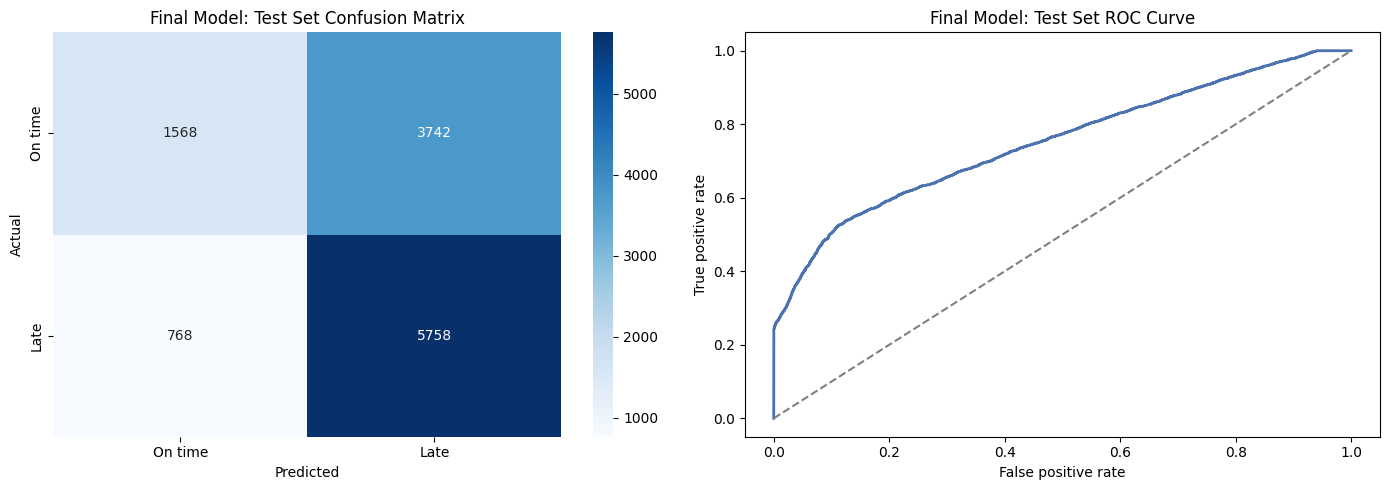

              precision    recall  f1-score   support

 On time (0)       0.67      0.30      0.41      5310
    Late (1)       0.61      0.88      0.72      6526

    accuracy                           0.62     11836
   macro avg       0.64      0.59      0.56     11836
weighted avg       0.64      0.62      0.58     11836

Top-K view on the test set (for the prioritization lens):


,ops can act on,share that are truly late,share of all late orders caught
0,top 5% (591 orders),1.000,0.091
1,top 10% (1183 orders),1.000,0.181
2,top 20% (2367 orders),0.931,0.338
3,top 30% (3550 orders),0.875,0.476


In [25]:
y_pred_final = (y_score_test >= CHOSEN_THRESHOLD).astype(int)

import seaborn as sns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm = confusion_matrix(y_test, y_pred_final)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On time', 'Late'], yticklabels=['On time', 'Late'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('Final Model: Test Set Confusion Matrix')

fpr, tpr, _ = roc_curve(y_test, y_score_test)
axes[1].plot(fpr, tpr, color='#4C72B0', linewidth=2)
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray')
axes[1].set_xlabel('False positive rate'); axes[1].set_ylabel('True positive rate')
axes[1].set_title('Final Model: Test Set ROC Curve')

plt.tight_layout()
plt.savefig(FIGS / 'final_test_evaluation.png', dpi=120, bbox_inches='tight')
plt.show()

print(classification_report(y_test, y_pred_final, target_names=['On time (0)', 'Late (1)']))
print("Top-K view on the test set (for the prioritization lens):")
top_k_table(y_test, y_score_test)

**What we found:** at the chosen threshold of 0.38, the final model catches **5,758 of the 6,526 late orders on the test set (88.2% Recall)** and misses 768. To do that it flags **9,500 of 11,836 orders (80%)**, and 3,742 of those flags are false alarms (Precision 60.6%).

In business terms, for every 100 orders: about 80 are flagged, about 49 of those are truly late, about 32 are false alarms, about 13 are correctly left alone, and about 6 late orders are missed.

**The honest reading is that this is a high-Recall, low-selectivity setup.** Only 1,568 of the 5,310 on-time orders (30%) are correctly cleared, so ops would still need to look at most orders. Flagging every order would give Recall 100% and Precision 55.1%, so the model's Precision of 60.6% is only 5.5 points above flagging everything, in exchange for 12 points of Recall. The model adds real value over a blanket "check everything" rule, but a modest amount at this threshold, and about 6% of late orders still go unnoticed.

**The top of the ranking is where the model is strongest.** On the test set the 10% of orders with the highest scores (1,183 orders) are all late, and the top 20% are 93% late. For the shipment prioritization lens, a ranked list of the highest-risk, highest-value orders is a far more selective and useful output than the yes/no flag.

**Recommendation for Stage 9:** present both uses of the model. The threshold gives a broad "watch list" with high Recall, and the ranked top of the list gives a short, high-confidence action queue.

### 8.4 Save the final results

In [26]:
final_results = {
    'model': type(final_model).__name__,
    'threshold': CHOSEN_THRESHOLD,
    'test_recall': float(recall_score(y_test, y_pred_final)),
    'test_precision': float(precision_score(y_test, y_pred_final)),
    'test_f1': float(f1_score(y_test, y_pred_final)),
    'test_roc_auc': float(roc_auc_score(y_test, y_score_test)),
    'test_pr_auc': float(average_precision_score(y_test, y_score_test)),
}
with open(DATA / 'final_test_results.json', 'w') as f:
    json.dump(final_results, f, indent=2)
print("Saved final test results:")
print(json.dumps(final_results, indent=2))

Saved final test results:
{
  "model": "RandomForestClassifier",
  "threshold": 0.38,
  "test_recall": 0.8823168863009501,
  "test_precision": 0.6061052631578947,
  "test_f1": 0.7185823037563959,
  "test_roc_auc": 0.7515464579462823,
  "test_pr_auc": 0.8227004592308239
}
